# Supervised Model

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
active_pairs = pd.read_csv("../data/manipulated/active_pairs.csv")

train_residuals = pd.read_csv("../data/manipulated/residuals_train.csv", index_col=0, parse_dates=True)
val_residuals = pd.read_csv("../data/manipulated/residuals_val.csv", index_col=0, parse_dates=True)
test_residuals = pd.read_csv("../data/manipulated/residuals_test.csv", index_col=0, parse_dates=True)

train_start = train_residuals.index.min()
train_end = train_residuals.index.max()

val_start = val_residuals.index.min()
val_end = val_residuals.index.max()

test_start = test_residuals.index.min()
test_end = test_residuals.index.max()

In [3]:
FEATURES = ["spread", "z_score", "regime"]
TARGET = "signal"

In [4]:
train_frames = []
val_frames = []
test_frames  = []

for _, row in active_pairs.iterrows():
    a, b, beta = row['asset_a'], row['asset_b'], row['beta']

    path = f'../data/manipulated/spreads/{a}_{b}.csv'
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    
    df = df[FEATURES + [TARGET]].dropna()
    train_frames.append(df.loc[train_start:train_end])
    val_frames.append(df.loc[val_start:val_end])
    test_frames.append(df.loc[test_start:test_end])

train_df = pd.concat(train_frames)
val_df = pd.concat(val_frames)
test_df  = pd.concat(test_frames)

print(f'Train rows: {len(train_df):,}  | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}')
print('Train class distribution:')
print(train_df[TARGET].value_counts().sort_index())

Train rows: 248,820  | Val rows: 33,264 | Test rows: 33,000
Train class distribution:
signal
-1     13889
 0    219244
 1     15687
Name: count, dtype: int64


<BarContainer object of 3 artists>

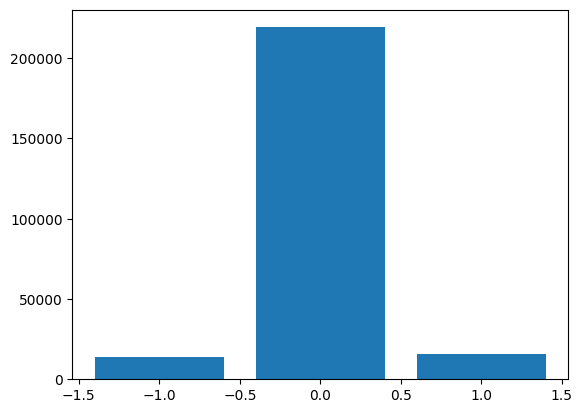

In [5]:
plt.bar([-1, 0, 1], train_df[TARGET].value_counts().sort_index())

In [6]:
X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_val = val_df[FEATURES].values
y_val = val_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

# Scale features (spread is raw price, z_score is normalised, regime is 0..k-1 - all different scales)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit only on train
X_val = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [7]:
model = LogisticRegression(
    solver='lbfgs',
    class_weight='balanced',   # handles 0-heavy imbalance
    max_iter=1000,
    random_state=42,
)
model.fit(X_train, y_train)
print('Classes:', model.classes_)

Classes: [-1  0  1]


In [8]:
# --- Training performance ---
y_train_pred = model.predict(X_train)
print('=== Train ===')
print(classification_report(y_train, y_train_pred, target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

=== Train ===
              precision    recall  f1-score   support

  Short (-1)       0.32      1.00      0.48     13889
    Exit (0)       1.00      0.74      0.85    219244
    Long (1)       0.37      1.00      0.54     15687

    accuracy                           0.77    248820
   macro avg       0.56      0.91      0.62    248820
weighted avg       0.92      0.77      0.81    248820



In [9]:
# --- Val performance ---
y_val_pred = model.predict(X_val)
print('=== Validation ===')
print(classification_report(y_val, y_val_pred, target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

=== Validation ===
              precision    recall  f1-score   support

  Short (-1)       0.35      1.00      0.51      1809
    Exit (0)       1.00      0.78      0.88     29465
    Long (1)       0.40      1.00      0.57      1990

    accuracy                           0.81     33264
   macro avg       0.58      0.93      0.65     33264
weighted avg       0.93      0.81      0.84     33264



In [10]:
coef_df = pd.DataFrame(model.coef_, index=[f"Class {c}" for c in model.classes_], columns=FEATURES)
print(coef_df.round(4))

          spread  z_score  regime
Class -1 -0.1595   3.9539 -0.0911
Class 0  -0.0217   0.0770  0.0330
Class 1   0.1812  -4.0309  0.0581


In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)
print('Classes:', model.classes_)

Classes: [-1  0  1]


In [12]:
# --- Training performance ---
y_train_pred = model.predict(X_train)
print('=== Train ===')
print(classification_report(y_train, y_train_pred, target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

=== Train ===
              precision    recall  f1-score   support

  Short (-1)       0.84      0.60      0.70     13889
    Exit (0)       0.97      0.98      0.97    219244
    Long (1)       0.81      0.88      0.84     15687

    accuracy                           0.95    248820
   macro avg       0.87      0.82      0.84    248820
weighted avg       0.95      0.95      0.95    248820



In [13]:
# --- Val performance ---
y_val_pred = model.predict(X_val)
print('=== Validation ===')
print(classification_report(y_val, y_val_pred, target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

=== Validation ===
              precision    recall  f1-score   support

  Short (-1)       0.86      0.60      0.71      1809
    Exit (0)       0.97      0.98      0.97     29465
    Long (1)       0.81      0.89      0.85      1990

    accuracy                           0.95     33264
   macro avg       0.88      0.82      0.84     33264
weighted avg       0.95      0.95      0.95     33264



In [14]:
importances = pd.Series(model.feature_importances_, index=FEATURES)
print(importances.sort_values())

regime     0.022013
spread     0.335904
z_score    0.642083
dtype: float64


In [15]:
# Write model_signal back to each spread CSV for use in backtest
for _, row in active_pairs.iterrows():
    a, b = row["asset_a"], row["asset_b"]
    path = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(path, index_col=0, parse_dates=True)

    valid = df[FEATURES].dropna()
    X = scaler.transform(valid.values)
    df.loc[valid.index, "model_signal"] = model.predict(X)
    df.to_csv(path)

print(f"model_signal written to {len(active_pairs)} spread files")

model_signal written to 132 spread files
